# Intelligent Spam Classification & Threat Triage Platform
## Notebook 04 — Hybrid System Evaluation

This notebook evaluates the production-style Hybrid architecture built after:

- `01_dataset_exploration.ipynb`
- `02_ml_baseline.ipynb`
- `03_security_feature_engineering.ipynb`

The objective is to answer:

> **Does the Hybrid architecture recover important threats missed by ML-only classification, and what operational cost does that improvement introduce?**

```text
Canonical Email
      │
      ├──────────────────────────────┐
      ▼                              ▼
TF-IDF + Logistic Regression   Deterministic Security
      │                        URL / Sender / Language
      └─────────────┬────────────────┘
                    ▼
               RiskEvidence
                    ▼
            Deterministic Risk
                    ▼
             Routing Policy
                    │
         ┌──────────┴──────────┐
         ▼                     ▼
   Direct Decision        AGENT_REVIEW
                               │
                               ▼
                        Google ADK + Gemini
                               │
                        Threat Intel Tools
                               │
                               ▼
                     Constrained Recommendation
```

### Experimental integrity

- The ML model is **not retrained** here.
- The decision threshold is loaded from Notebook 02 artifacts.
- The locked test set remains the benchmark.
- A direct `GEMINI_ONLY` benchmark is intentionally deferred because the current production review agent consumes upstream ML/risk/routing evidence. Calling it “Gemini-only” would be methodologically misleading.


## 1. Environment Setup

Run from the repository root in Colab:

```text
/content/intelligent-spam-threat-triage
```

Expected artifacts:

```text
artifacts/ml_baseline/
├── tfidf_logistic_regression.joblib
└── metrics.json
```


In [1]:
# Cell 1 — Colab environment setup

%cd /content/intelligent-spam-threat-triage

# External dependencies only.
# Editable install is intentionally avoided for the manually uploaded ZIP workflow.
%pip install -q python-dotenv google-adk matplotlib joblib pandas numpy scikit-learn

import importlib
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/intelligent-spam-threat-triage")
SRC_PATH = PROJECT_ROOT / "src"
PACKAGE_PATH = SRC_PATH / "threat_triage"

assert SRC_PATH.exists(), f"Missing source directory: {SRC_PATH}"
assert PACKAGE_PATH.exists(), f"Missing package directory: {PACKAGE_PATH}"
assert (PACKAGE_PATH / "__init__.py").exists(), "Missing threat_triage/__init__.py"

src_string = str(SRC_PATH.resolve())

# Put the project src directory first and refresh Python's import cache.
sys.path = [
    path
    for path in sys.path
    if path != src_string
]
sys.path.insert(0, src_string)

sys.path_importer_cache.pop(src_string, None)
importlib.invalidate_caches()

import threat_triage

print("Repository root :", PROJECT_ROOT)
print("Source path     :", SRC_PATH)
print("threat_triage   : PASSED")
print("Loaded from     :", threat_triage.__file__)

/content/intelligent-spam-threat-triage
Repository root : /content/intelligent-spam-threat-triage
Source path     : /content/intelligent-spam-threat-triage/src
threat_triage   : PASSED
Loaded from     : /content/intelligent-spam-threat-triage/src/threat_triage/__init__.py


In [37]:
# Cell 2 — Imports and configuration

from __future__ import annotations

import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dotenv import load_dotenv

from threat_triage.data_loader import (
    CANONICAL_COLUMNS,
    get_train_validation_test,
)

from threat_triage.evaluation.adapters import (
    HybridEvaluationAdapter,
    MLArtifactAdapter,
)

from threat_triage.evaluation.comparison import (
    build_evaluation_comparison,
    compare_ml_to_hybrid,
)

from threat_triage.evaluation.evaluator import (
    evaluate_batch,
    evaluate_hybrid_sample,
)

from threat_triage.evaluation.metrics import (
    compute_evaluation_metrics,
)

from threat_triage.evaluation.models import (
    EvaluationLabel,
    EvaluationMode,
    EvaluationSample,
)

from threat_triage.risk.evidence_builder import build_risk_evidence
from threat_triage.risk.risk_scorer import score_risk
from threat_triage.risk.routing_policy import route_message
from threat_triage.risk.models import RoutingDecision
from threat_triage.security.feature_extractor import extract_security_features
from threat_triage.agents.adk_runner import run_agent_review

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()

GEMINI_MODEL = os.getenv(
    "THREAT_TRIAGE_GEMINI_MODEL",
    "gemini-2.5-flash",
)

print("Imports loaded successfully.")
print("Project root :", PROJECT_ROOT)
print("Gemini model:", GEMINI_MODEL)


Imports loaded successfully.
Project root : /content/intelligent-spam-threat-triage
Gemini model: gemini-2.5-flash


## 2. Load Environment Configuration

Notebook 04 runs in Google Colab and reads API credentials from **Colab Secrets**.

Expected secret names:

```text
GOOGLE_API_KEY
VIRUSTOTAL_API_KEY
```

The values are copied into runtime environment variables for the production modules, but the secret values are never printed.


In [3]:
# Cell 3 — Load API credentials from Google Colab Secrets

import os
from google.colab import userdata


def load_colab_secret(
    secret_name: str,
    env_name: str,
) -> bool:
    """
    Load a secret from Google Colab Secrets and expose it
    as an environment variable for production modules.

    The secret value is never printed.
    """
    try:
        value = userdata.get(secret_name)

        if value and value.strip():
            os.environ[env_name] = value.strip()
            return True

    except Exception:
        pass

    return False


HAS_GEMINI_KEY = load_colab_secret(
    "GOOGLE_API_KEY",
    "GEMINI_API_KEY",
)

HAS_VIRUSTOTAL_KEY = load_colab_secret(
    "VIRUSTOTAL_API_KEY",
    "VIRUSTOTAL_API_KEY",
)


print(
    "Gemini credential configured    :",
    HAS_GEMINI_KEY,
)

print(
    "VirusTotal credential configured:",
    HAS_VIRUSTOTAL_KEY,
)

Gemini credential configured    : True
VirusTotal credential configured: True


## 3. Load Canonical Dataset

Reuse the same split policy as Notebooks 02 and 03:

- original train → train + validation
- original test → locked test
- validation size = 20%
- random state = 42


In [4]:
# Cell 4 — Load train / validation / locked test

splits = get_train_validation_test(
    validation_size=0.20,
    random_state=RANDOM_STATE,
)

train_df = splits.train
validation_df = splits.validation
test_df = splits.test


def add_evaluation_id(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Create a stable row-level evaluation identity without changing
    the source dataset's original message_id.

    Some source message_id values are duplicated, while the evaluation
    framework requires unique sample IDs for dictionaries, joins, and
    per-sample comparisons.
    """
    result = dataframe.copy()

    occurrence = (
        result
        .groupby(
            "message_id",
            dropna=False,
        )
        .cumcount()
    )

    result["evaluation_id"] = (
        result["message_id"].astype(str)
        + "::"
        + occurrence.astype(str)
    )

    return result


# Keep test_df canonical for Notebook 02 consistency.
# evaluation_test_df is the Notebook 04 row-identity view.
evaluation_test_df = add_evaluation_id(
    test_df
)

print("Train           :", train_df.shape)
print("Validation      :", validation_df.shape)
print("Locked test     :", test_df.shape)
print("Evaluation view :", evaluation_test_df.shape)

print()
print(
    "Duplicate source message IDs:",
    int(test_df["message_id"].duplicated().sum()),
)

print(
    "Unique evaluation IDs       :",
    evaluation_test_df["evaluation_id"].nunique(),
)

README.md:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  184MB            

train.parquet: downloading bytes:           |  0.00B            

test.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

test.parquet: downloading bytes:           |  0.00B            

eval.parquet: reconstructing file:   0%|          |  0.00B / 22.7MB            

eval.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/162413 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40604 [00:00<?, ? examples/s]

Train           : (129930, 12)
Validation      : (32483, 12)
Locked test     : (40604, 12)
Evaluation view : (40604, 13)

Duplicate source message IDs: 18
Unique evaluation IDs       : 40604


In [5]:
# Cell 5 — Validate canonical schema and evaluation identity

assert list(train_df.columns) == CANONICAL_COLUMNS
assert list(validation_df.columns) == CANONICAL_COLUMNS
assert list(test_df.columns) == CANONICAL_COLUMNS

assert list(
    evaluation_test_df[
        CANONICAL_COLUMNS
    ].columns
) == CANONICAL_COLUMNS

assert test_df["message_id"].notna().all()
assert test_df["combined_text"].notna().all()
assert set(test_df["label_id"].unique()).issubset({0, 1})

assert len(evaluation_test_df) == len(test_df)

assert (
    evaluation_test_df["evaluation_id"].nunique()
    == len(evaluation_test_df)
)

print("Canonical schema validation : PASSED")
print("Evaluation ID validation    : PASSED")

display(
    test_df["canonical_label"]
    .value_counts()
    .rename_axis("label")
    .to_frame("rows")
)

Canonical schema validation : PASSED
Evaluation ID validation    : PASSED


,rows
label,
BENIGN,21738
THREAT,18866


## 4. Load Locked ML Baseline

Notebook 02 already locked:

- fitted TF-IDF + Logistic Regression pipeline,
- validation-selected operating threshold,
- locked-test metrics.

Notebook 04 must reuse those artifacts exactly.


In [6]:
# Cell 6 — Resolve and validate baseline artifacts

MODEL_PATH = PROJECT_ROOT / "artifacts" / "ml_baseline" / "tfidf_logistic_regression.joblib"
METRICS_PATH = PROJECT_ROOT / "artifacts" / "ml_baseline" / "metrics.json"

print("Model exists  :", MODEL_PATH.exists())
print("Metrics exists:", METRICS_PATH.exists())

assert MODEL_PATH.exists(), "Notebook 02 model artifact is missing."
assert METRICS_PATH.exists(), "Notebook 02 metrics.json is missing."


Model exists  : True
Metrics exists: True


In [7]:
# Cell 7 — Load model and locked threshold

baseline_model = joblib.load(MODEL_PATH)

with open(METRICS_PATH, "r", encoding="utf-8") as file:
    baseline_metadata = json.load(file)

SELECTED_THRESHOLD = float(
    baseline_metadata["selected_threshold"]
)

print("Baseline artifact loaded.")
print("Selected threshold:", round(SELECTED_THRESHOLD, 6))

if "test_metrics" in baseline_metadata:
    display(
        pd.Series(
            baseline_metadata["test_metrics"]
        ).round(4)
    )


Baseline artifact loaded.
Selected threshold: 0.736383


,0
accuracy,0.9735
precision,0.9935
recall,0.9493
f1,0.9709
roc_auc,0.9984
pr_auc,0.9981


## 5. Create Evaluation Adapters and Samples

The new B1–B5 evaluation framework normalizes sklearn, deterministic security, risk/routing, and agent outputs into comparable evaluation contracts.


In [8]:
# Cell 8 — ML evaluation adapter

ml_adapter = MLArtifactAdapter(
    model=baseline_model,
    decision_threshold=SELECTED_THRESHOLD,
    model_name="tfidf-logistic-regression",
    model_version="0.1.0",
)

print("MLArtifactAdapter created.")


MLArtifactAdapter created.


In [9]:
# Cell 9 — Canonical row → EvaluationSample

def row_to_evaluation_sample(
    row: pd.Series,
) -> EvaluationSample:
    label = (
        EvaluationLabel.THREAT
        if int(row["label_id"]) == 1
        else EvaluationLabel.BENIGN
    )

    return EvaluationSample(
        sample_id=str(
            row["evaluation_id"]
        ),

        subject=(
            None
            if pd.isna(row["subject"])
            else str(row["subject"])
        ),

        body=(
            None
            if pd.isna(row["body"])
            else str(row["body"])
        ),

        sender=(
            None
            if pd.isna(row["sender"])
            else str(row["sender"])
        ),

        true_label=label,

        urls=(),

        # The canonical dataset is binary BENIGN / THREAT and does not
        # provide a verified fine-grained phishing taxonomy.
        threat_category=None,

        source=(
            None
            if pd.isna(row["source_dataset"])
            else str(row["source_dataset"])
        ),
    )


test_samples = [
    row_to_evaluation_sample(row)
    for _, row
    in evaluation_test_df.iterrows()
]

assert len(test_samples) == len(evaluation_test_df)

assert (
    len(
        {
            sample.sample_id
            for sample in test_samples
        }
    )
    == len(test_samples)
)

print(
    "Evaluation samples:",
    len(test_samples),
)

print(
    "Unique EvaluationSample IDs:",
    len(
        {
            sample.sample_id
            for sample in test_samples
        }
    ),
)

print(
    "EvaluationSample identity validation: PASSED"
)

Evaluation samples: 40604
Unique EvaluationSample IDs: 40604
EvaluationSample identity validation: PASSED


# 6. Experiment A — Full Locked-Test ML_ONLY

First validate that the B1–B5 evaluation framework reproduces the already-locked Notebook 02 baseline.


In [10]:
# Cell 10 — Execute ML_ONLY on full locked test

start = time.perf_counter()

ml_results = await evaluate_batch(
    test_samples,
    mode=EvaluationMode.ML_ONLY,
    executor=ml_adapter.evaluate,
    agent_invoked=False,
)

print("ML results:", len(ml_results))
print("Failures  :", sum(r.error is not None for r in ml_results))
print("Seconds   :", round(time.perf_counter() - start, 3))


ML results: 40604
Failures  : 0
Seconds   : 49.56


In [11]:
# Cell 11 — Compute full-test ML metrics

ml_metrics = compute_evaluation_metrics(
    ml_results,
    mode=EvaluationMode.ML_ONLY,
)

ml_metrics_series = pd.Series(
    {
        "total_samples": ml_metrics.total_samples,
        "successful_samples": ml_metrics.successful_samples,
        "failed_samples": ml_metrics.failed_samples,
        "true_positive": ml_metrics.true_positive,
        "true_negative": ml_metrics.true_negative,
        "false_positive": ml_metrics.false_positive,
        "false_negative": ml_metrics.false_negative,
        "accuracy": ml_metrics.accuracy,
        "precision": ml_metrics.precision,
        "recall": ml_metrics.recall,
        "f1": ml_metrics.f1,
        "false_positive_rate": ml_metrics.false_positive_rate,
        "false_negative_rate": ml_metrics.false_negative_rate,
        "phishing_recall": ml_metrics.phishing_recall,
        "agent_invocation_rate": ml_metrics.agent_invocation_rate,
        "average_latency_ms": ml_metrics.average_latency_ms,
    }
)

display(ml_metrics_series.round(4))


,0
total_samples,40604.0000
successful_samples,40604.0000
failed_samples,0.0000
true_positive,17909.0000
true_negative,21620.0000
false_positive,118.0000
false_negative,957.0000
accuracy,0.9735
precision,0.9935
recall,0.9493


In [12]:
# Cell 12 — Cross-check against Notebook 02 saved metrics

saved = baseline_metadata.get("test_metrics", {})

rows = []

for name, current in {
    "accuracy": ml_metrics.accuracy,
    "precision": ml_metrics.precision,
    "recall": ml_metrics.recall,
    "f1": ml_metrics.f1,
}.items():
    if name in saved:
        rows.append(
            {
                "metric": name,
                "notebook_02": float(saved[name]),
                "notebook_04": current,
                "absolute_difference": abs(current - float(saved[name])),
            }
        )

if rows:
    consistency_df = pd.DataFrame(rows)
    display(consistency_df.round(8))

    assert consistency_df["absolute_difference"].max() < 1e-6

    print("Notebook 02 ↔ Notebook 04 metric consistency: PASSED")
else:
    print("Saved metrics did not contain comparable keys; check skipped.")


,metric,notebook_02,notebook_04,absolute_difference
0,accuracy,0.973525,0.973525,0.0
1,precision,0.993454,0.993454,0.0
2,recall,0.949274,0.949274,0.0
3,f1,0.970862,0.970862,0.0


Notebook 02 ↔ Notebook 04 metric consistency: PASSED


## 7. ML Baseline Visualizations


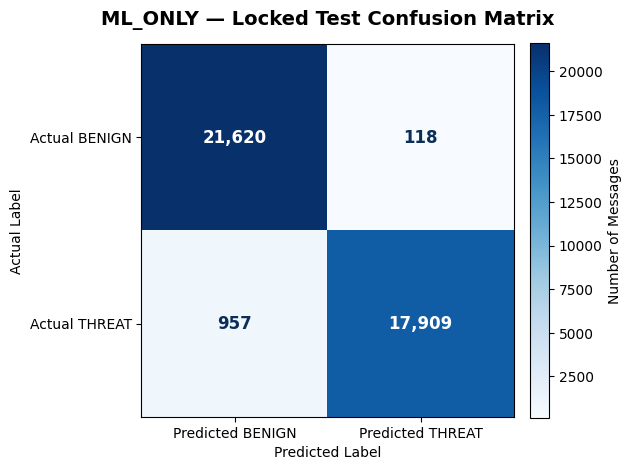

In [13]:
# Cell 13 — ML confusion matrix

matrix = np.array(
    [
        [
            ml_metrics.true_negative,
            ml_metrics.false_positive,
        ],
        [
            ml_metrics.false_negative,
            ml_metrics.true_positive,
        ],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    matrix,
    cmap="Blues",
)

ax.set_xticks(
    [0, 1],
    labels=[
        "Predicted BENIGN",
        "Predicted THREAT",
    ],
)

ax.set_yticks(
    [0, 1],
    labels=[
        "Actual BENIGN",
        "Actual THREAT",
    ],
)

threshold = matrix.max() / 2

for row_index in range(2):
    for column_index in range(2):
        value = matrix[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=(
                "white"
                if value > threshold
                else "#0B2E59"
            ),
        )

ax.set_title(
    "ML_ONLY — Locked Test Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "Actual Label"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Number of Messages"
)

plt.tight_layout()
plt.show()

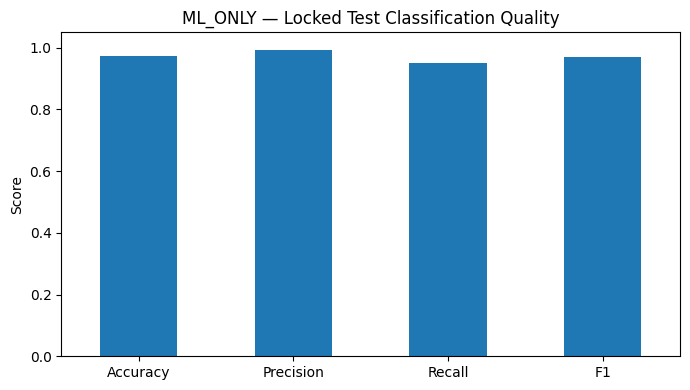

In [14]:
# Cell 14 — ML quality chart

quality = pd.Series(
    {
        "Accuracy": ml_metrics.accuracy,
        "Precision": ml_metrics.precision,
        "Recall": ml_metrics.recall,
        "F1": ml_metrics.f1,
    }
)

ax = quality.plot(kind="bar", figsize=(7, 4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("ML_ONLY — Locked Test Classification Quality")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 8. Build an ML Error Table

Notebook 03 established that deterministic security evidence can exist inside ML false negatives. Notebook 04 converts that observation into a bounded Hybrid challenge experiment.


In [15]:
# Cell 15 — Recreate vectorized locked-test predictions

# Use canonical combined_text exactly as Notebook 02 did.
ml_probability = baseline_model.predict_proba(
    test_df["combined_text"]
)[:, 1]

ml_prediction = (
    ml_probability
    >= SELECTED_THRESHOLD
).astype(int)

# evaluation_test_df has the same row order as test_df plus evaluation_id.
test_scored = evaluation_test_df[
    [
        "evaluation_id",
        "message_id",
        "subject",
        "body",
        "sender",
        "source_dataset",
        "canonical_label",
        "label_id",
    ]
].copy()

test_scored[
    "ml_threat_probability"
] = ml_probability

test_scored[
    "ml_prediction"
] = ml_prediction

test_scored[
    "ml_outcome"
] = np.select(
    [
        (
            (test_scored["label_id"] == 1)
            & (test_scored["ml_prediction"] == 1)
        ),
        (
            (test_scored["label_id"] == 0)
            & (test_scored["ml_prediction"] == 0)
        ),
        (
            (test_scored["label_id"] == 0)
            & (test_scored["ml_prediction"] == 1)
        ),
        (
            (test_scored["label_id"] == 1)
            & (test_scored["ml_prediction"] == 0)
        ),
    ],
    [
        "TRUE_POSITIVE",
        "TRUE_NEGATIVE",
        "FALSE_POSITIVE",
        "FALSE_NEGATIVE",
    ],
    default="UNKNOWN",
)

assert (
    test_scored["evaluation_id"].nunique()
    == len(test_scored)
)

display(
    test_scored[
        "ml_outcome"
    ]
    .value_counts()
    .rename_axis("outcome")
    .to_frame("rows")
)

,rows
outcome,
TRUE_NEGATIVE,21620
TRUE_POSITIVE,17909
FALSE_NEGATIVE,957
FALSE_POSITIVE,118


In [16]:
# Cell 16 — Inspect ML false negatives

ml_false_negatives = test_scored[
    test_scored["ml_outcome"] == "FALSE_NEGATIVE"
].copy()

print("ML false negatives:", len(ml_false_negatives))

display(
    ml_false_negatives[
        [
            "message_id",
            "source_dataset",
            "ml_threat_probability",
            "subject",
        ]
    ]
    .sort_values("ml_threat_probability", ascending=False)
    .head(20)
)


ML false negatives: 957


,message_id,source_dataset,ml_threat_probability,subject
3581,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9,CEAS-08,0.736037,Original und deren Wirkung
31391,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e,TREC-05,0.735802,Discover(R) Card News Online - January 2002
16805,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104,TREC-05,0.735518,jgo hard the cheapi way
23801,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173,TREC-05,0.735351,
11242,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf,TREC-05,0.735251,The time is now - geet the neww vigra pro annette
8639,a16621bf2824ff219b0d959af8b6740a4bef61a65702afa57fe5490192d2aaca,TREC-06,0.735147,zipping my energy
1077,baffa03782d0d2447c38610446ff5220184f8710a7c6c8709a3d35646c3f3641,Enron,0.735118,winning one of our chopard and feel the triumph on your wrist .
25900,8964c4bc8b7dc27df1d2af82b6beb550e2629de49db46e73225927610e4490ac,TREC-07,0.735111,IMMEDIATE INVESTOR ALERT!
37600,9298439ccd498b5d63009bbc2bd0ca4b5fc6e9b3373265c167334d4f2a6a51c7,TREC-05,0.734771,"cials-tabs, limited supply available"
940,2f6dcab9eed1add5457f318bd1e3fc6aace9762574de81a9611cb3b9a2b770bd,Enron,0.734475,$ judgements child support detective


# 9. Build the Hybrid Challenge Set

The first live Hybrid benchmark should be bounded and failure-focused rather than sending the entire historical test corpus to Gemini.

Challenge buckets:

1. ML false negatives — primary recovery cases.
2. ML false positives — over-triage cases when available.
3. ML true positives — threat controls.
4. ML true negatives — benign controls.

The subset is intentionally error-enriched. It is **not** a prevalence-representative benchmark.


In [17]:
# Cell 17 — Challenge configuration

CHALLENGE_ROWS_PER_BUCKET = 5
MAX_LIVE_CHALLENGE_SAMPLES = 12

print("Rows per bucket        :", CHALLENGE_ROWS_PER_BUCKET)
print("Max live Hybrid samples:", MAX_LIVE_CHALLENGE_SAMPLES)


Rows per bucket        : 5
Max live Hybrid samples: 12


In [18]:
# Cell 18 — Build deterministic challenge set

parts = []

for outcome in [
    "FALSE_NEGATIVE",
    "FALSE_POSITIVE",
    "TRUE_POSITIVE",
    "TRUE_NEGATIVE",
]:
    subset = test_scored[
        test_scored["ml_outcome"] == outcome
    ].copy()

    if subset.empty:
        continue

    n = min(CHALLENGE_ROWS_PER_BUCKET, len(subset))

    if outcome == "FALSE_NEGATIVE":
        chosen = (
            subset
            .sort_values("ml_threat_probability", ascending=False)
            .head(n)
        )
    else:
        chosen = subset.sample(n=n, random_state=RANDOM_STATE)

    parts.append(chosen)

challenge_df = (
    pd.concat(parts, ignore_index=True)
    .drop_duplicates(subset=["evaluation_id"])
    .reset_index(drop=True)
)

assert len(challenge_df) > 0

print("Challenge rows:", len(challenge_df))

display(
    challenge_df["ml_outcome"]
    .value_counts()
    .rename_axis("ML outcome")
    .to_frame("rows")
)


Challenge rows: 20


,rows
ML outcome,
FALSE_NEGATIVE,5
FALSE_POSITIVE,5
TRUE_POSITIVE,5
TRUE_NEGATIVE,5


In [19]:
# Cell 19 — Challenge EvaluationSamples

test_by_evaluation_id = (
    evaluation_test_df
    .set_index(
        "evaluation_id",
        drop=False,
    )
)

challenge_samples = [
    row_to_evaluation_sample(
        test_by_evaluation_id.loc[
            evaluation_id
        ]
    )
    for evaluation_id
    in challenge_df[
        "evaluation_id"
    ].tolist()
]

assert (
    len(challenge_samples)
    == len(challenge_df)
)

assert (
    len(
        {
            sample.sample_id
            for sample in challenge_samples
        }
    )
    == len(challenge_samples)
)

print(
    "Challenge EvaluationSamples:",
    len(challenge_samples),
)

print(
    "Challenge sample IDs are unique: PASSED"
)

Challenge EvaluationSamples: 20
Challenge sample IDs are unique: PASSED


# 10. Preview Deterministic Hybrid Routing

Before any live Gemini request, evaluate the existing production security, risk, and routing layers.

This identifies:

- direct decisions,
- `AGENT_REVIEW` cases,
- `HUMAN_REVIEW` cases,
- risk scores,
- strong-signal counts.


In [20]:
# Cell 20 — Hybrid route preview helper

def preview_hybrid_route(
    sample: EvaluationSample,
) -> dict:
    ml_evidence = (
        ml_adapter
        .build_ml_evidence(
            sample
        )
    )

    security_features = (
        extract_security_features(
            message_id=sample.sample_id,
            subject=sample.subject,
            body=sample.body,
            sender=sample.sender,
        )
    )

    risk_evidence = (
        build_risk_evidence(
            message_id=sample.sample_id,
            ml_evidence=ml_evidence,
            security_features=security_features,
        )
    )

    assessment = score_risk(
        risk_evidence
    )

    routing = route_message(
        evidence=risk_evidence,
        assessment=assessment,
    )

    return {
        "ml_evidence": ml_evidence,
        "risk_evidence": risk_evidence,
        "assessment": assessment,
        "routing": routing,
    }


route_preview_by_id = {}
route_rows = []

for sample in challenge_samples:
    preview = preview_hybrid_route(
        sample
    )

    route_preview_by_id[
        sample.sample_id
    ] = preview

    route_rows.append(
        {
            "evaluation_id": (
                sample.sample_id
            ),
            "true_label": (
                sample.true_label.value
            ),
            "ml_probability": (
                preview[
                    "ml_evidence"
                ].threat_probability
            ),
            "ml_prediction": (
                preview[
                    "ml_evidence"
                ].predicted_label
            ),
            "risk_score": (
                preview[
                    "assessment"
                ].risk_score
            ),
            "severity": (
                preview[
                    "assessment"
                ].severity.value
            ),
            "total_signals": (
                preview[
                    "risk_evidence"
                ]
                .summary
                .total_signal_count
            ),
            "strong_signal_count": len(
                preview[
                    "risk_evidence"
                ]
                .summary
                .strong_signals
            ),
            "strong_signal_names": ", ".join(
                preview[
                    "risk_evidence"
                ]
                .summary
                .strong_signals
            ),
            "requires_deep_analysis": (
                preview[
                    "assessment"
                ].requires_deep_analysis
            ),
            "routing_decision": (
                preview[
                    "routing"
                ].decision.value
            ),
        }
    )

route_preview_df = pd.DataFrame(
    route_rows
)

assert (
    route_preview_df[
        "evaluation_id"
    ].nunique()
    == len(route_preview_df)
)

display(
    route_preview_df
)

,evaluation_id,true_label,ml_probability,ml_prediction,risk_score,severity,total_signals,strong_signal_count,strong_signal_names,requires_deep_analysis,routing_decision
0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0,THREAT,0.736037,BENIGN,44.16,MEDIUM,0,0,,True,AGENT_REVIEW
1,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e::0,THREAT,0.735802,BENIGN,56.15,HIGH,3,1,lang_financial,True,AGENT_REVIEW
2,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104::0,THREAT,0.735518,BENIGN,44.13,MEDIUM,0,0,,True,AGENT_REVIEW
3,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173::0,THREAT,0.735351,BENIGN,44.12,MEDIUM,0,0,,True,AGENT_REVIEW
4,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf::0,THREAT,0.735251,BENIGN,44.12,MEDIUM,0,0,,True,AGENT_REVIEW
5,1fff641934c2b8cebc498d020200afae2ba75581e0c4e20f745e514e96f50b60::0,BENIGN,0.844382,THREAT,52.66,HIGH,1,0,,False,AGENT_REVIEW
6,7a86cbb005fb06f4406169e21829143567cf8a95c1521fe82c8873cb0fa89512::0,BENIGN,0.820133,THREAT,49.21,MEDIUM,0,0,,False,AGENT_REVIEW
7,3020f814f170dbf658abffb46ae03ad9286a563694f5ce42ace9fe6194fa75db::0,BENIGN,0.750188,THREAT,55.01,HIGH,2,1,lang_financial,True,AGENT_REVIEW
8,55aa23b8e40256a58b53dfa41791543d6f31a720de115cf96e75b25b483d1c3e::0,BENIGN,0.932969,THREAT,57.98,HIGH,1,0,,False,AGENT_REVIEW
9,0b5c7ae31a3a5a33cd4066c73be465e57b6a8d3e39444eb2dc919e34414362f7::0,BENIGN,0.864001,THREAT,53.84,HIGH,1,0,,False,AGENT_REVIEW


In [21]:
# Cell 21 — Routing summary

routing_summary = (
    route_preview_df["routing_decision"]
    .value_counts()
    .rename_axis("routing_decision")
    .to_frame("rows")
)

routing_summary["percentage"] = (
    routing_summary["rows"]
    / len(route_preview_df)
    * 100
).round(2)

display(routing_summary)

agent_review_candidates = int(
    (
        route_preview_df["routing_decision"]
        == RoutingDecision.AGENT_REVIEW.value
    ).sum()
)

print("AGENT_REVIEW candidates:", agent_review_candidates)


,rows,percentage
routing_decision,,
AGENT_REVIEW,16,80.0
ALLOW,4,20.0


AGENT_REVIEW candidates: 16


In [22]:
# Cell 22 — Risk by ML outcome

route_analysis = (
    challenge_df[
        [
            "evaluation_id",
            "message_id",
            "ml_outcome",
        ]
    ]
    .merge(
        route_preview_df,
        on="evaluation_id",
        how="left",
        validate="one_to_one",
    )
)

assert len(route_analysis) == len(challenge_df)

display(
    route_analysis
    .groupby(
        "ml_outcome"
    )
    .agg(
        rows=(
            "evaluation_id",
            "size",
        ),
        mean_risk_score=(
            "risk_score",
            "mean",
        ),
        median_risk_score=(
            "risk_score",
            "median",
        ),
        mean_total_signals=(
            "total_signals",
            "mean",
        ),
        mean_strong_signals=(
            "strong_signal_count",
            "mean",
        ),
    )
    .round(2)
)

,rows,mean_risk_score,median_risk_score,mean_total_signals,mean_strong_signals
ml_outcome,,,,,
FALSE_NEGATIVE,5,46.54,44.13,0.6,0.2
FALSE_POSITIVE,5,53.74,53.84,1.0,0.2
TRUE_NEGATIVE,5,8.55,4.65,0.2,0.0
TRUE_POSITIVE,5,58.87,59.24,0.2,0.0


In [24]:
# Cell 22A — Select first live AGENT_REVIEW case

agent_review_rows = route_analysis[
    route_analysis["routing_decision"]
    == RoutingDecision.AGENT_REVIEW.value
].copy()

print(
    "AGENT_REVIEW candidates:",
    len(agent_review_rows),
)

display(
    agent_review_rows[
        [
            "evaluation_id",
            "message_id",
            "ml_outcome",
            "true_label",
            "ml_probability",
            "risk_score",
            "total_signals",
            "strong_signal_count",
        ]
    ]
)

AGENT_REVIEW candidates: 16


,evaluation_id,message_id,ml_outcome,true_label,ml_probability,risk_score,total_signals,strong_signal_count
0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9,FALSE_NEGATIVE,THREAT,0.736037,44.16,0,0
1,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e::0,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e,FALSE_NEGATIVE,THREAT,0.735802,56.15,3,1
2,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104::0,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104,FALSE_NEGATIVE,THREAT,0.735518,44.13,0,0
3,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173::0,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173,FALSE_NEGATIVE,THREAT,0.735351,44.12,0,0
4,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf::0,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf,FALSE_NEGATIVE,THREAT,0.735251,44.12,0,0
5,1fff641934c2b8cebc498d020200afae2ba75581e0c4e20f745e514e96f50b60::0,1fff641934c2b8cebc498d020200afae2ba75581e0c4e20f745e514e96f50b60,FALSE_POSITIVE,BENIGN,0.844382,52.66,1,0
6,7a86cbb005fb06f4406169e21829143567cf8a95c1521fe82c8873cb0fa89512::0,7a86cbb005fb06f4406169e21829143567cf8a95c1521fe82c8873cb0fa89512,FALSE_POSITIVE,BENIGN,0.820133,49.21,0,0
7,3020f814f170dbf658abffb46ae03ad9286a563694f5ce42ace9fe6194fa75db::0,3020f814f170dbf658abffb46ae03ad9286a563694f5ce42ace9fe6194fa75db,FALSE_POSITIVE,BENIGN,0.750188,55.01,2,1
8,55aa23b8e40256a58b53dfa41791543d6f31a720de115cf96e75b25b483d1c3e::0,55aa23b8e40256a58b53dfa41791543d6f31a720de115cf96e75b25b483d1c3e,FALSE_POSITIVE,BENIGN,0.932969,57.98,1,0
9,0b5c7ae31a3a5a33cd4066c73be465e57b6a8d3e39444eb2dc919e34414362f7::0,0b5c7ae31a3a5a33cd4066c73be465e57b6a8d3e39444eb2dc919e34414362f7,FALSE_POSITIVE,BENIGN,0.864001,53.84,1,0


In [27]:
# Cell 22B — Build one-sample live smoke set

assert len(agent_review_rows) > 0, (
    "No AGENT_REVIEW candidate available."
)

FIRST_LIVE_EVALUATION_ID = (
    agent_review_rows
    .iloc[0]["evaluation_id"]
)

first_live_sample = next(
    sample
    for sample in challenge_samples
    if sample.sample_id
    == FIRST_LIVE_EVALUATION_ID
)

live_challenge_samples = [
    first_live_sample
]

print(
    "First live sample:",
    first_live_sample.sample_id,
)

print(
    "Live sample count:",
    len(live_challenge_samples),
)

First live sample: 58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0
Live sample count: 1


# 11. Live Hybrid Evaluation

The notebook defaults to dry-run mode.

For the first live evaluation, change:

```python
RUN_LIVE_HYBRID = True
```

Keep the first run small because Gemini may invoke VirusTotal and other agent tools.

The same challenge samples will later be evaluated with ML-only and Hybrid so the comparison uses identical rows.


In [34]:
# Cell 23 — Live switch

RUN_LIVE_HYBRID = True
print("RUN_LIVE_HYBRID:", RUN_LIVE_HYBRID)

if RUN_LIVE_HYBRID:
    assert HAS_GEMINI_KEY, (
        "Gemini API key is required for live Hybrid evaluation."
    )

RUN_LIVE_HYBRID: True


In [41]:
# Cell 24 — Hybrid production adapter
GEMINI_MODEL = "gemini-3.5-flash-lite"

hybrid_adapter = HybridEvaluationAdapter(
    ml_adapter=ml_adapter,
    agent_executor=run_agent_review,
    gemini_model=GEMINI_MODEL,
)

live_challenge_samples = challenge_samples[
    :MAX_LIVE_CHALLENGE_SAMPLES
]

print("Live challenge rows:", len(live_challenge_samples))


Live challenge rows: 12


In [42]:
# Cell 25 — Fail-fast sequential Hybrid evaluation

import asyncio
import time


BETWEEN_MESSAGES_SECONDS = 10

hybrid_results = []
benchmark_aborted = False


if not RUN_LIVE_HYBRID:

    print(
        "Hybrid live execution skipped."
    )

else:

    assert hybrid_adapter is not None

    benchmark_start = time.perf_counter()

    total_samples = len(
        live_challenge_samples
    )

    for index, sample in enumerate(
        live_challenge_samples,
        start=1,
    ):

        preview = (
            route_preview_by_id[
                sample.sample_id
            ]
        )

        agent_invoked = (
            preview["routing"].decision
            == RoutingDecision.AGENT_REVIEW
        )

        print()
        print("=" * 70)

        print(
            f"[{index}/{total_samples}]"
        )

        print(
            "Evaluation ID:",
            sample.sample_id,
        )

        print(
            "Route:",
            preview["routing"].decision.value,
        )

        print(
            "Agent invoked:",
            agent_invoked,
        )

        # -----------------------------------------------------
        # Exactly ONE execution attempt.
        # -----------------------------------------------------

        try:

            result = (
                await evaluate_hybrid_sample(
                    sample,
                    executor=(
                        hybrid_adapter.evaluate
                    ),
                    agent_invoked=(
                        agent_invoked
                    ),
                )
            )

        except Exception as exc:

            # A provider/runtime exception escaped the
            # evaluation boundary.
            print()
            print(
                "Result: FAILED"
            )

            print(
                "Exception type:",
                type(exc).__name__,
            )

            print(
                "Benchmark aborted."
            )

            benchmark_aborted = True

            # CRITICAL:
            # Do NOT execute the next message.
            break


        hybrid_results.append(
            result
        )


        # -----------------------------------------------------
        # Fail-fast on EvaluationResult.error
        # -----------------------------------------------------

        if result.error is not None:

            print()
            print(
                "Result: FAILED"
            )

            print(
                "Error:",
                result.error,
            )

            print()
            print(
                "Benchmark aborted."
            )

            benchmark_aborted = True

            # CRITICAL:
            # Exit the for-loop immediately.
            break


        # -----------------------------------------------------
        # Successful sample
        # -----------------------------------------------------

        print(
            "Result: SUCCESS"
        )

        print(
            "Latency:",
            round(
                result.latency_ms / 1000.0,
                2,
            ),
            "seconds",
        )


        # -----------------------------------------------------
        # Wait ONLY after success.
        # -----------------------------------------------------

        if index < total_samples:

            print(
                "Waiting",
                BETWEEN_MESSAGES_SECONDS,
                "seconds before next message..."
            )

            await asyncio.sleep(
                BETWEEN_MESSAGES_SECONDS
            )


    elapsed = (
        time.perf_counter()
        - benchmark_start
    )

    print()
    print("=" * 70)

    if benchmark_aborted:

        print(
            "HYBRID EVALUATION ABORTED"
        )

    else:

        print(
            "HYBRID EVALUATION COMPLETE"
        )

    print(
        "Completed results:",
        len(hybrid_results),
        "/",
        total_samples,
    )

    print(
        "Successful:",
        sum(
            result.error is None
            for result in hybrid_results
        ),
    )

    print(
        "Failed:",
        sum(
            result.error is not None
            for result in hybrid_results
        ),
    )

    print(
        "Total runtime:",
        round(
            elapsed,
            2,
        ),
        "seconds",
    )


[1/12]
Evaluation ID: 58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0
Route: AGENT_REVIEW
Agent invoked: True
Result: SUCCESS
Latency: 4.4 seconds
Waiting 20 seconds before next message...

[2/12]
Evaluation ID: 2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e::0
Route: AGENT_REVIEW
Agent invoked: True
Result: SUCCESS
Latency: 7.91 seconds
Waiting 20 seconds before next message...

[3/12]
Evaluation ID: 2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104::0
Route: AGENT_REVIEW
Agent invoked: True
Result: SUCCESS
Latency: 5.17 seconds
Waiting 20 seconds before next message...

[4/12]
Evaluation ID: c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173::0
Route: AGENT_REVIEW
Agent invoked: True
Result: SUCCESS
Latency: 3.68 seconds
Waiting 20 seconds before next message...

[5/12]
Evaluation ID: ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf::0
Route: AGENT_REVIEW
Agent invoked: True
Result: SUCCESS
Latency: 5

# 12. Compare ML_ONLY and HYBRID on Identical Challenge Rows

Do **not** compare full-test ML metrics with challenge-set Hybrid metrics.

Both modes are recalculated on the exact same live challenge sample IDs.


In [43]:
# Cell 26 — ML evaluation on exact live challenge rows

live_ml_results = await evaluate_batch(
    live_challenge_samples,
    mode=EvaluationMode.ML_ONLY,
    executor=ml_adapter.evaluate,
    agent_invoked=False,
)

live_ml_metrics = compute_evaluation_metrics(
    live_ml_results,
    mode=EvaluationMode.ML_ONLY,
)

print("Challenge-set ML metrics ready.")


Challenge-set ML metrics ready.


In [44]:
# Cell 27 — Hybrid metrics and comparison

hybrid_metrics = None
hybrid_comparison = None
evaluation_comparison = None

if hybrid_results:
    hybrid_metrics = compute_evaluation_metrics(
        hybrid_results,
        mode=EvaluationMode.HYBRID,
    )

    metrics_by_mode = {
        EvaluationMode.ML_ONLY: live_ml_metrics,
        EvaluationMode.HYBRID: hybrid_metrics,
    }

    evaluation_comparison = build_evaluation_comparison(
        metrics_by_mode
    )

    hybrid_comparison = compare_ml_to_hybrid(
        metrics_by_mode
    )

    print("ML ↔ Hybrid comparison created.")
else:
    print("Run live Hybrid evaluation first.")


ML ↔ Hybrid comparison created.


In [45]:
# Cell 28 — Challenge metric table

if hybrid_metrics is not None:
    metric_table = pd.DataFrame(
        [
            {
                "mode": "ML_ONLY",
                "accuracy": live_ml_metrics.accuracy,
                "precision": live_ml_metrics.precision,
                "recall": live_ml_metrics.recall,
                "f1": live_ml_metrics.f1,
                "false_positive_rate": live_ml_metrics.false_positive_rate,
                "false_negative_rate": live_ml_metrics.false_negative_rate,
                "agent_invocation_rate": live_ml_metrics.agent_invocation_rate,
                "average_latency_ms": live_ml_metrics.average_latency_ms,
                "failed_samples": live_ml_metrics.failed_samples,
            },
            {
                "mode": "HYBRID",
                "accuracy": hybrid_metrics.accuracy,
                "precision": hybrid_metrics.precision,
                "recall": hybrid_metrics.recall,
                "f1": hybrid_metrics.f1,
                "false_positive_rate": hybrid_metrics.false_positive_rate,
                "false_negative_rate": hybrid_metrics.false_negative_rate,
                "agent_invocation_rate": hybrid_metrics.agent_invocation_rate,
                "average_latency_ms": hybrid_metrics.average_latency_ms,
                "failed_samples": hybrid_metrics.failed_samples,
            },
        ]
    ).set_index("mode")

    display(metric_table.round(4))
else:
    print("Run live Hybrid evaluation first.")


,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,agent_invocation_rate,average_latency_ms,failed_samples
mode,,,,,,,,,
ML_ONLY,0.1667,0.2857,0.2857,0.2857,1.0,0.7143,0.0,2.3792,0
HYBRID,0.5833,0.6250,0.7143,0.6667,0.6,0.2857,1.0,5236.1301,0


In [46]:
# Cell 29 — Detailed ML → Hybrid deltas

if hybrid_comparison is not None:
    rows = []

    for name in [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "false_positive_rate",
        "false_negative_rate",
        "agent_invocation_rate",
        "average_latency_ms",
    ]:
        delta = getattr(hybrid_comparison, name)

        rows.append(
            {
                "metric": name,
                "ML_ONLY": delta.baseline_value,
                "HYBRID": delta.candidate_value,
                "absolute_delta": delta.absolute_delta,
                "relative_delta": delta.relative_delta,
            }
        )

    delta_table = pd.DataFrame(rows).set_index("metric")
    display(delta_table.round(4))
else:
    print("Run live Hybrid evaluation first.")


,ML_ONLY,HYBRID,absolute_delta,relative_delta
metric,,,,
accuracy,0.1667,0.5833,0.4167,2.5000
precision,0.2857,0.6250,0.3393,1.1875
recall,0.2857,0.7143,0.4286,1.5000
f1,0.2857,0.6667,0.3810,1.3333
false_positive_rate,1.0000,0.6000,-0.4000,-0.4000
false_negative_rate,0.7143,0.2857,-0.4286,-0.6000
agent_invocation_rate,0.0000,1.0000,1.0000,NaN
average_latency_ms,2.3792,5236.1301,5233.7508,2199.7699


## 13. Quality and Operational Trade-offs


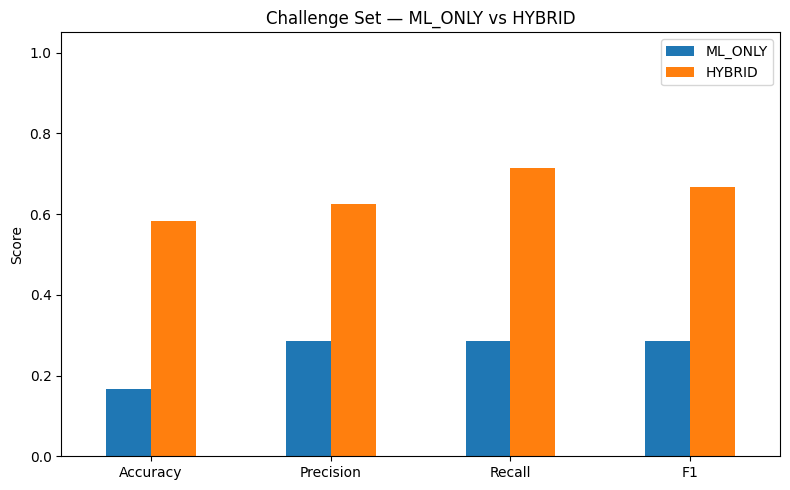

In [47]:
# Cell 30 — ML vs Hybrid quality

if hybrid_metrics is not None:
    quality_comparison = pd.DataFrame(
        {
            "ML_ONLY": [
                live_ml_metrics.accuracy,
                live_ml_metrics.precision,
                live_ml_metrics.recall,
                live_ml_metrics.f1,
            ],
            "HYBRID": [
                hybrid_metrics.accuracy,
                hybrid_metrics.precision,
                hybrid_metrics.recall,
                hybrid_metrics.f1,
            ],
        },
        index=["Accuracy", "Precision", "Recall", "F1"],
    )

    ax = quality_comparison.plot(kind="bar", figsize=(8, 5))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Challenge Set — ML_ONLY vs HYBRID")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Run live Hybrid evaluation first.")


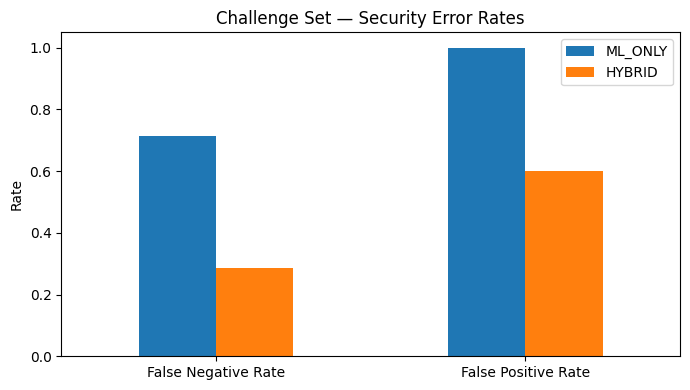

In [48]:
# Cell 31 — Security error rates

if hybrid_metrics is not None:
    errors = pd.DataFrame(
        {
            "ML_ONLY": [
                live_ml_metrics.false_negative_rate,
                live_ml_metrics.false_positive_rate,
            ],
            "HYBRID": [
                hybrid_metrics.false_negative_rate,
                hybrid_metrics.false_positive_rate,
            ],
        },
        index=["False Negative Rate", "False Positive Rate"],
    )

    ax = errors.plot(kind="bar", figsize=(7, 4))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate")
    ax.set_title("Challenge Set — Security Error Rates")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Run live Hybrid evaluation first.")


In [49]:
# Cell 32 — Operational trade-off table

if hybrid_metrics is not None:
    operational = pd.DataFrame(
        {
            "ML_ONLY": {
                "average_latency_ms": live_ml_metrics.average_latency_ms,
                "agent_invocation_rate": live_ml_metrics.agent_invocation_rate,
            },
            "HYBRID": {
                "average_latency_ms": hybrid_metrics.average_latency_ms,
                "agent_invocation_rate": hybrid_metrics.agent_invocation_rate,
            },
        }
    )

    display(operational.round(4))
else:
    print("Run live Hybrid evaluation first.")


,ML_ONLY,HYBRID
average_latency_ms,2.3792,5236.1301
agent_invocation_rate,0.0000,1.0000


# 14. ML False-Negative Recovery

This is the central architecture experiment:

```text
Actual THREAT
    +
ML_ONLY BENIGN
        ↓
Does HYBRID change the result to THREAT?
```


In [50]:
# Cell 33 — Per-sample comparison

sample_comparison_df = pd.DataFrame()

if hybrid_results:
    ml_by_id = {
        result.sample_id: result
        for result in live_ml_results
    }

    hybrid_by_id = {
        result.sample_id: result
        for result in hybrid_results
    }

    original_message_id = (
        challenge_df
        .set_index(
            "evaluation_id"
        )[
            "message_id"
        ]
        .to_dict()
    )

    rows = []

    for sample in live_challenge_samples:
        ml_result = ml_by_id[
            sample.sample_id
        ]

        hybrid_result = hybrid_by_id[
            sample.sample_id
        ]

        preview = route_preview_by_id[
            sample.sample_id
        ]

        rows.append(
            {
                "evaluation_id": (
                    sample.sample_id
                ),
                "message_id": (
                    original_message_id.get(
                        sample.sample_id
                    )
                ),
                "true_label": (
                    sample.true_label.value
                ),
                "ml_label": (
                    ml_result
                    .prediction
                    .predicted_label
                    .value
                    if ml_result.prediction
                    else None
                ),
                "hybrid_label": (
                    hybrid_result
                    .prediction
                    .predicted_label
                    .value
                    if hybrid_result.prediction
                    else None
                ),
                "ml_probability": (
                    ml_result
                    .prediction
                    .threat_probability
                    if ml_result.prediction
                    else None
                ),
                "risk_score": (
                    preview[
                        "assessment"
                    ].risk_score
                ),
                "routing_decision": (
                    preview[
                        "routing"
                    ].decision.value
                ),
                "strong_signals": ", ".join(
                    preview[
                        "risk_evidence"
                    ]
                    .summary
                    .strong_signals
                ),
                "agent_invoked": (
                    hybrid_result
                    .agent_invoked
                ),
                "hybrid_disposition": (
                    hybrid_result
                    .prediction
                    .disposition
                    .value
                    if hybrid_result.prediction
                    else None
                ),
                "error": (
                    hybrid_result.error
                ),
            }
        )

    sample_comparison_df = (
        pd.DataFrame(
            rows
        )
    )

    display(
        sample_comparison_df
    )

else:
    print(
        "Run live Hybrid evaluation first."
    )

,evaluation_id,message_id,true_label,ml_label,hybrid_label,ml_probability,risk_score,routing_decision,strong_signals,agent_invoked,hybrid_disposition,error
0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9,THREAT,BENIGN,BENIGN,0.736037,44.16,AGENT_REVIEW,,True,ALLOW,None
1,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e::0,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e,THREAT,BENIGN,THREAT,0.735802,56.15,AGENT_REVIEW,lang_financial,True,MONITOR,None
2,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104::0,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104,THREAT,BENIGN,BENIGN,0.735518,44.13,AGENT_REVIEW,,True,ALLOW,None
3,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173::0,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173,THREAT,BENIGN,THREAT,0.735351,44.12,AGENT_REVIEW,,True,MONITOR,None
4,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf::0,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf,THREAT,BENIGN,THREAT,0.735251,44.12,AGENT_REVIEW,,True,QUARANTINE,None
5,1fff641934c2b8cebc498d020200afae2ba75581e0c4e20f745e514e96f50b60::0,1fff641934c2b8cebc498d020200afae2ba75581e0c4e20f745e514e96f50b60,BENIGN,THREAT,THREAT,0.844382,52.66,AGENT_REVIEW,,True,MONITOR,None
6,7a86cbb005fb06f4406169e21829143567cf8a95c1521fe82c8873cb0fa89512::0,7a86cbb005fb06f4406169e21829143567cf8a95c1521fe82c8873cb0fa89512,BENIGN,THREAT,BENIGN,0.820133,49.21,AGENT_REVIEW,,True,ALLOW,None
7,3020f814f170dbf658abffb46ae03ad9286a563694f5ce42ace9fe6194fa75db::0,3020f814f170dbf658abffb46ae03ad9286a563694f5ce42ace9fe6194fa75db,BENIGN,THREAT,THREAT,0.750188,55.01,AGENT_REVIEW,lang_financial,True,MONITOR,None
8,55aa23b8e40256a58b53dfa41791543d6f31a720de115cf96e75b25b483d1c3e::0,55aa23b8e40256a58b53dfa41791543d6f31a720de115cf96e75b25b483d1c3e,BENIGN,THREAT,BENIGN,0.932969,57.98,AGENT_REVIEW,,True,ALLOW,None
9,0b5c7ae31a3a5a33cd4066c73be465e57b6a8d3e39444eb2dc919e34414362f7::0,0b5c7ae31a3a5a33cd4066c73be465e57b6a8d3e39444eb2dc919e34414362f7,BENIGN,THREAT,THREAT,0.864001,53.84,AGENT_REVIEW,,True,MONITOR,None


In [51]:
# Cell 34 — False negatives recovered by Hybrid

recovery_df = pd.DataFrame()

if len(sample_comparison_df) > 0:
    recovery_df = sample_comparison_df[
        (sample_comparison_df["true_label"] == "THREAT")
        & (sample_comparison_df["ml_label"] == "BENIGN")
    ].copy()

    recovery_df["recovered_by_hybrid"] = (
        recovery_df["hybrid_label"] == "THREAT"
    )

    print("ML false negatives in live challenge:", len(recovery_df))

    if len(recovery_df) > 0:
        print(
            "Hybrid recovery rate:",
            round(float(recovery_df["recovered_by_hybrid"].mean()), 4),
        )

        display(recovery_df)
else:
    print("Run live Hybrid evaluation first.")


ML false negatives in live challenge: 5
Hybrid recovery rate: 0.6


,evaluation_id,message_id,true_label,ml_label,hybrid_label,ml_probability,risk_score,routing_decision,strong_signals,agent_invoked,hybrid_disposition,error,recovered_by_hybrid
0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9::0,58646cb37b0772755c032843c2b6fdaae1c5a9471f54adfdf1ea54a7d44830f9,THREAT,BENIGN,BENIGN,0.736037,44.16,AGENT_REVIEW,,True,ALLOW,None,False
1,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e::0,2b3727494e04abb9b10b7cb9310616dbcd60b6bf151a34a5dfbf94e5b9b0332e,THREAT,BENIGN,THREAT,0.735802,56.15,AGENT_REVIEW,lang_financial,True,MONITOR,None,True
2,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104::0,2ad0800ca316b35c5e4dbfad075abcddaf9d8cca231ef72ac177a0b452ddd104,THREAT,BENIGN,BENIGN,0.735518,44.13,AGENT_REVIEW,,True,ALLOW,None,False
3,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173::0,c23f0be0ce78e2ad5feb6ce0a6fee4835ce1bffd6fd932f0b236c1c7eb81a173,THREAT,BENIGN,THREAT,0.735351,44.12,AGENT_REVIEW,,True,MONITOR,None,True
4,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf::0,ccc17d1bb158e6632d62127a20556f18e629717d628f064cf593eb3494660fdf,THREAT,BENIGN,THREAT,0.735251,44.12,AGENT_REVIEW,,True,QUARANTINE,None,True


In [52]:
# Cell 35 — Recovery mechanism

if len(recovery_df) > 0:
    display(
        recovery_df
        .groupby(
            [
                "routing_decision",
                "agent_invoked",
                "recovered_by_hybrid",
            ]
        )
        .size()
        .rename("rows")
        .reset_index()
    )
else:
    print("No recovery rows available yet.")


,routing_decision,agent_invoked,recovered_by_hybrid,rows
0,AGENT_REVIEW,True,False,2
1,AGENT_REVIEW,True,True,3


# 15. Evidence-Backed Architecture Findings

The next cell generates only statements supported by actual outputs. Keep these findings when you later write the final notebook analysis.


In [53]:
# Cell 36 — Generate findings

findings = [
    (
        "The locked ML baseline evaluated "
        f"{ml_metrics.total_samples} samples with "
        f"recall={ml_metrics.recall:.4f}, "
        f"F1={ml_metrics.f1:.4f}, and "
        f"false-negative-rate={ml_metrics.false_negative_rate:.4f}."
    ),
    (
        "The ML baseline produced "
        f"{ml_metrics.false_negative} false negatives "
        "on the locked test set."
    ),
    (
        "The Hybrid challenge set contains "
        f"{len(challenge_samples)} samples, including "
        f"{int((challenge_df['ml_outcome'] == 'FALSE_NEGATIVE').sum())} "
        "ML false negatives."
    ),
    (
        "Deterministic routing marked "
        f"{agent_review_candidates} challenge samples "
        "for AGENT_REVIEW before any live Gemini execution."
    ),
]

if hybrid_metrics is not None:
    findings.extend(
        [
            (
                "On the same live challenge rows, Hybrid recall was "
                f"{hybrid_metrics.recall:.4f} versus "
                f"{live_ml_metrics.recall:.4f} for ML-only."
            ),
            (
                "On the same live challenge rows, Hybrid false-negative-rate was "
                f"{hybrid_metrics.false_negative_rate:.4f} versus "
                f"{live_ml_metrics.false_negative_rate:.4f} for ML-only."
            ),
            (
                "Hybrid invoked the agent for "
                f"{hybrid_metrics.agent_invocation_rate:.2%} "
                "of live challenge samples."
            ),
            (
                "Average Hybrid latency was "
                f"{hybrid_metrics.average_latency_ms:.2f} ms versus "
                f"{live_ml_metrics.average_latency_ms:.2f} ms for ML-only."
            ),
        ]
    )

    if len(recovery_df) > 0:
        findings.append(
            (
                "Hybrid recovered "
                f"{int(recovery_df['recovered_by_hybrid'].sum())}/"
                f"{len(recovery_df)} ML false negatives represented "
                "in the live challenge."
            )
        )

for index, finding in enumerate(findings, start=1):
    print(f"{index}. {finding}")


1. The locked ML baseline evaluated 40604 samples with recall=0.9493, F1=0.9709, and false-negative-rate=0.0507.
2. The ML baseline produced 957 false negatives on the locked test set.
3. The Hybrid challenge set contains 20 samples, including 5 ML false negatives.
4. Deterministic routing marked 16 challenge samples for AGENT_REVIEW before any live Gemini execution.
5. On the same live challenge rows, Hybrid recall was 0.7143 versus 0.2857 for ML-only.
6. On the same live challenge rows, Hybrid false-negative-rate was 0.2857 versus 0.7143 for ML-only.
7. Hybrid invoked the agent for 100.00% of live challenge samples.
8. Average Hybrid latency was 5236.13 ms versus 2.38 ms for ML-only.
9. Hybrid recovered 3/5 ML false negatives represented in the live challenge.


# 16. Limitations

### Challenge-set selection
The live Hybrid benchmark deliberately oversamples ML errors. It is useful for failure recovery analysis, but it is **not** representative of production prevalence.

### Model and provider nondeterminism
Gemini/tool outputs may vary over time. Record model/version/date when using results for formal comparison.

### Binary threat taxonomy
The current canonical evaluation is `BENIGN / THREAT`. Fine-grained labels should not be inferred without source-supported taxonomy.

### Historical dataset
Historical email corpora may not represent modern enterprise phishing/BEC distributions.

### Gemini-only benchmark
A true direct Gemini-only benchmark is deferred until a separate tested raw-message contract exists.

### Cost
This notebook measures latency and agent invocation rate. Do not fabricate token/cost values without telemetry.


# 17. Persist Evaluation Artifacts

Artifacts intentionally exclude full message bodies.


In [54]:
# Cell 37 — Create artifact directory

EVALUATION_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "evaluation"
)

EVALUATION_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Artifact directory:", EVALUATION_ARTIFACT_DIR)


Artifact directory: /content/intelligent-spam-threat-triage/artifacts/evaluation


In [55]:
# Cell 38 — Save full-test ML and challenge routing artifacts

ml_summary = {
    "mode": EvaluationMode.ML_ONLY.value,
    "selected_threshold": SELECTED_THRESHOLD,
    "metrics": {
        "total_samples": ml_metrics.total_samples,
        "successful_samples": ml_metrics.successful_samples,
        "failed_samples": ml_metrics.failed_samples,
        "true_positive": ml_metrics.true_positive,
        "true_negative": ml_metrics.true_negative,
        "false_positive": ml_metrics.false_positive,
        "false_negative": ml_metrics.false_negative,
        "accuracy": ml_metrics.accuracy,
        "precision": ml_metrics.precision,
        "recall": ml_metrics.recall,
        "f1": ml_metrics.f1,
        "false_positive_rate": (
            ml_metrics.false_positive_rate
        ),
        "false_negative_rate": (
            ml_metrics.false_negative_rate
        ),
        "average_latency_ms": (
            ml_metrics.average_latency_ms
        ),
    },
}

with open(
    EVALUATION_ARTIFACT_DIR
    / "ml_locked_test_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ml_summary,
        file,
        indent=2,
    )

challenge_df[
    [
        "evaluation_id",
        "message_id",
        "source_dataset",
        "canonical_label",
        "label_id",
        "ml_threat_probability",
        "ml_prediction",
        "ml_outcome",
    ]
].to_csv(
    EVALUATION_ARTIFACT_DIR
    / "hybrid_challenge_set.csv",
    index=False,
)

route_analysis.to_csv(
    EVALUATION_ARTIFACT_DIR
    / "hybrid_route_preview.csv",
    index=False,
)

print(
    "Saved ML and deterministic routing artifacts."
)

Saved ML and deterministic routing artifacts.


In [56]:
# Cell 39 — Save live comparison when available

if hybrid_metrics is not None:
    summary = {
        "gemini_model": GEMINI_MODEL,
        "live_sample_count": len(live_challenge_samples),
        "ml_only": {
            "accuracy": live_ml_metrics.accuracy,
            "precision": live_ml_metrics.precision,
            "recall": live_ml_metrics.recall,
            "f1": live_ml_metrics.f1,
            "false_positive_rate": live_ml_metrics.false_positive_rate,
            "false_negative_rate": live_ml_metrics.false_negative_rate,
            "average_latency_ms": live_ml_metrics.average_latency_ms,
        },
        "hybrid": {
            "accuracy": hybrid_metrics.accuracy,
            "precision": hybrid_metrics.precision,
            "recall": hybrid_metrics.recall,
            "f1": hybrid_metrics.f1,
            "false_positive_rate": hybrid_metrics.false_positive_rate,
            "false_negative_rate": hybrid_metrics.false_negative_rate,
            "agent_invocation_rate": hybrid_metrics.agent_invocation_rate,
            "average_latency_ms": hybrid_metrics.average_latency_ms,
            "failed_samples": hybrid_metrics.failed_samples,
        },
    }

    with open(
        EVALUATION_ARTIFACT_DIR / "ml_vs_hybrid_challenge_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(summary, file, indent=2)

    sample_comparison_df.to_csv(
        EVALUATION_ARTIFACT_DIR / "ml_vs_hybrid_sample_results.csv",
        index=False,
    )

    print("Saved live ML vs Hybrid comparison artifacts.")
else:
    print("Live Hybrid artifacts skipped until live evaluation is run.")


Saved live ML vs Hybrid comparison artifacts.


# 18. Final Hybrid Evaluation Analysis

## A. Classical ML Baseline

The locked-test ML baseline was reproduced successfully on the canonical test split.

Locked-test metrics:

- Accuracy: **0.973525**
- Precision: **0.993454**
- Recall: **0.949274**
- F1: **0.970862**

These metrics represent the population-level performance of the classical ML baseline on the full locked test set.

The live Hybrid experiment below uses a deliberately difficult, error-enriched challenge subset and therefore must not be interpreted as population-wide performance.


## B. Deterministic Risk and Routing

The challenge set was constructed from selected ML true positives, true negatives, false positives, and false negatives.

The deterministic security layer enriched each message with security evidence before risk scoring and routing.

For the final live benchmark:

- **12 messages** were evaluated.
- All **12/12** were routed to `AGENT_REVIEW`.
- Gemini was invoked for all **12/12** challenge samples.
- The benchmark used **`gemini-3.5-flash-lite`**.
- All **12 evaluations completed successfully**.
- Provider/runtime failures: **0**.

The 100% agent invocation rate is specific to this deliberately difficult challenge subset and should not be interpreted as the expected production invocation rate.


## C. ML_ONLY vs HYBRID

The ML-only and Hybrid systems were evaluated on exactly the same 12 challenge messages.

| Metric | ML_ONLY | HYBRID |
|---|---:|---:|
| Accuracy | 0.1667 | **0.5833** |
| Precision | 0.2857 | **0.6250** |
| Recall | 0.2857 | **0.7143** |
| F1 | 0.2857 | **0.6667** |
| False Positive Rate | 1.0000 | **0.6000** |
| False Negative Rate | 0.7143 | **0.2857** |
| Agent Invocation Rate | 0.0000 | 1.0000 |
| Average Latency | ~2.38 ms | ~5236 ms |

On this selected challenge set, the Hybrid architecture substantially improved threat detection.

Threat recall increased from:

**28.57% → 71.43%**

while the false-negative rate decreased from:

**71.43% → 28.57%**.

The false-positive rate also decreased from **1.00 to 0.60**.


## D. False-Negative Recovery

The live challenge contained **5 threats that the baseline ML classifier classified as BENIGN**.

The Hybrid system recovered **3 of these 5 false negatives**:

**False-negative recovery rate = 60%**

Recovery summary:

- ML false negatives: **5**
- Recovered by Hybrid: **3**
- Remaining Hybrid false negatives: **2**

Two recovered cases had risk scores around 44 without strong deterministic signals, demonstrating the value of escalating uncertain cases for semantic agent review.

However, two ML false negatives remained classified as benign even after agent review. This demonstrates that LLM-assisted escalation reduces but does not eliminate classification errors.


## E. Operational Trade-off

The improved challenge-set detection introduced additional latency.

Average latency:

- ML_ONLY: approximately **2.38 ms**
- HYBRID: approximately **5.24 seconds**

The final `gemini-3.5-flash-lite` benchmark completed:

- **12 / 12 successful**
- **0 failed**
- total benchmark runtime: approximately **283 seconds**

The total runtime also includes the intentional 20-second pacing between live requests.

The Hybrid architecture therefore trades additional inference latency and external-provider dependency for deeper contextual analysis of selected high-risk or ambiguous messages.


## F. Architecture Finding

The experiment supports the following conclusion:

> On the deliberately difficult challenge subset, the Hybrid architecture recovered 3 of 5 threats missed by the classical ML classifier, increasing threat recall from 28.6% to 71.4%. The improvement was achieved by combining classical ML, deterministic security evidence, risk-based routing, and Gemini-backed agent review. This benefit introduces additional latency and dependency on an external model provider.

These challenge-set results do **not** establish population-wide superiority of the Hybrid system.

The locked-test ML metrics remain the appropriate measure of general baseline performance, while the challenge experiment demonstrates the Hybrid architecture's ability to recover selected difficult ML failure cases.

# 19. Phase Conclusion

Notebook 04 successfully connects and evaluates the implemented threat-triage layers:

```text
Notebook 01 — Dataset understanding
      ↓
Notebook 02 — Locked ML baseline
      ↓
Notebook 03 — Deterministic security evidence
      ↓
Risk Scoring + Routing
      ↓
Google ADK / Gemini Agent Review
      ↓
Threat Intelligence
      ↓
Notebook 04 — Hybrid System Evaluation
## Completion Checklist

- [ ] Repository installed
- [ ] canonical locked test reproduced
- [ ] Notebook 02 artifacts loaded
- [ ] ML adapter created
- [ ] full `ML_ONLY` evaluation completed
- [ ] Notebook 02 metrics reproduced
- [ ] ML false negatives identified
- [ ] Hybrid challenge set created
- [ ] deterministic routing preview completed
- [ ] live Gemini credential verified
- [ ] first bounded Hybrid run completed
- [ ] ML and Hybrid compared on identical rows
- [ ] false-negative recovery measured
- [ ] agent invocation rate measured
- [ ] latency trade-off measured
- [ ] evaluation artifacts exported
- [ ] final findings rewritten from actual output

### Next after Notebook 04

```text
B7 — Portfolio-ready evaluation report / artifacts
      ↓
Phase B Complete
      ↓
Push to Git
      ↓
Phase C — FastAPI Service
```
